# Optimising a cavity inside a beam line

A cavity is usually optimised on its own and then installed. `cavsim2d` can
optimise it in place, with its neighbours present: the bellows, the beam
pipes and the absorber are part of the meshed structure, so every objective is
evaluated on the geometry that will actually be built.

The mechanics are the ordinary optimisation config. The only thing an assembly
changes is the variable names, which are namespaced by element label — and that
is what lets one config reach into a single device inside a longer line.

This notebook is live: every figure below is produced by running `cavsim2d`.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import (Assembly, Beampipe, Bellows, EllipticalCavity, Study)
from cavsim2d.utils.style import apply_style, WARM

apply_style()
workspace = tempfile.mkdtemp()

# A TESLA-like mid cell: A, B, a, b, Ri, L, Req  (mm)
MIDCELL = [62.22, 66.13, 30.22, 23.11, 80.0, 93.5, 171.20]
R_IRIS = MIDCELL[4]

## 1. The line

One cavity between a bellows and two beam pipes. The cavity is the thing being
shaped; everything else is fixed hardware that it has to work inside.

Assembly('line', bp_l + bellows + cav + bp_r, 435 mm)


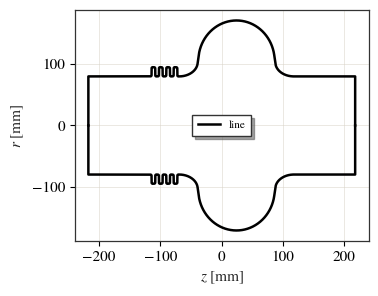

In [2]:
line = Assembly([
    Beampipe(R=R_IRIS, L=100.0, name='bp_l'),
    Bellows(Ri=R_IRIS, A=15.0, L_p=12.0, N_conv=4, R_root=2.0, R_crest=2.0),
    EllipticalCavity(1, MIDCELL, beampipe='none', name='cav'),
    Beampipe(R=R_IRIS, L=100.0, name='bp_r'),
], name='line')

print(repr(line))
ax = line.plot('geometry', mirror=True, show=False)
ax.legend(loc='center', fontsize=8)
plt.show()

## 2. What varies, and what does not

The bounds name element variables, `'<label>:<name>'`. Here four cell-wall
dimensions of the cavity are free, and `cav:Req` is the tune variable: every
candidate is tuned back to 800 MHz before its objectives are read, so the search
compares shapes at constant frequency rather than rediscovering the frequency.

Two dimensions are deliberately not free:

* `cav:Ri` is the iris radius, and it is shared with the beam pipes either side.
  Varying it alone would open a step at both junctions. To sweep the aperture,
  vary the pipes and the bellows bore with it.
* `cav:L` sets the cell length, which fixes the synchronous phase advance.

Bounds also have to stay inside the region where the cell geometry closes. An
elliptical cell whose wall ellipses cannot be joined tangentially is degenerate;
those candidates build no profile and drop out of the generation, so bounds that
stray far outside the feasible region waste evaluations.

In [3]:
config = {
    'initial_points': 8,
    'no_of_generation': 2,
    'method': {'LHS': {'seed': 7}},

    # element variables, namespaced by label
    'bounds': {'cav:A': [56, 63], 'cav:B': [62, 70],
               'cav:a': [27, 33], 'cav:b': [20, 26]},

    'objectives': [['max', 'monopole:R/Q [Ohm]'],
                   ['min', 'monopole:Epk/Eacc []']],

    # every candidate is tuned to 800 MHz on the cavity's equator radius
    'tune_config': {
        'freqs': 800.0,
        'cell_type': {'mid-cell': 'cav:Req'},
        'processes': 1,
        'tol': 1e-2,                     # MHz; see the note in the module example
        'eigenmode_config': {'processes': 1, 'boundary_conditions': 'mm',
                             'mesh_config': {'h': 10, 'p': 2}},
    },

    'mutation_factor': 2, 'crossover_factor': 2, 'elites_for_crossover': 2,
    'chaos_factor': 2, 'weights': [1, 1],
}

study = Study(os.path.join(workspace, 'opt'))
study.add_cavity([line], ['line'])

## 3. Running it

Each candidate is a full tune — several eigenmode solves on the whole line — so
this is the slow cell. Eight starting points and two generations is enough to
show a front; a production run would use more of both.

  0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\Soske\anaconda3\envs\cavsim2d\Lib\site-packages\scipy\optimize\_root_scalar.py:305: RuntimeWarning: Tolerance of 8.560000000000002 reached.
  r, sol = methodc(f, x0, args=args, fprime=None, fprime2=None,


 50%|█████     | 1/2 [01:49<01:49, 109.02s/it]

100%|██████████| 2/2 [03:12<00:00, 93.74s/it] 

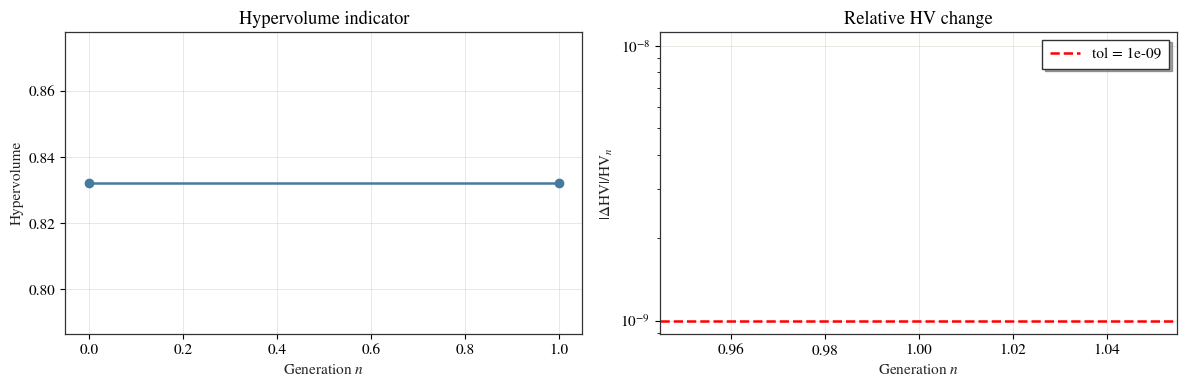

evaluated : 7 candidates
objectives: ['monopole:R/Q [Ohm]', 'monopole:Epk/Eacc []']


In [4]:
study.run_optimisation(config)

opt = study.optimisation
print(f'evaluated : {len(opt.history)} candidates')
print(f'objectives: {opt.objective_vars}')

In [5]:
cols = [c for c in opt.history.columns
        if c.startswith('cav:') or c.startswith('monopole:')]
opt.history[cols].round(3)

,cav:A,cav:B,cav:a,cav:b,cav:Req,monopole:R/Q [Ohm],monopole:Epk/Eacc []
0,59.938,62.5,27.375,24.125,172.612,83.865,4.551
1,61.688,65.5,30.375,23.375,171.565,84.789,4.948
2,60.812,66.5,32.625,21.125,171.415,85.230,5.533
3,56.438,69.5,29.625,24.875,175.194,82.846,4.494
4,57.312,63.5,28.125,21.875,173.809,83.519,4.559
5,59.062,67.5,31.875,20.375,172.652,84.534,5.176
6,58.188,64.5,28.875,22.625,173.449,83.716,4.636


`cav:Req` is in the table even though it was not a bounds variable: it is the
tune variable, so it carries whatever value brought each candidate to 800 MHz.
Its spread is a direct read on how much each shape changed the cavity.

## 4. The front

Two objectives that pull against each other give a set of non-dominated
candidates rather than a single winner. `opt.pareto` is that set, and
`plot_pareto()` draws it.

In [6]:
opt.pareto[cols].round(3)

,cav:A,cav:B,cav:a,cav:b,cav:Req,monopole:R/Q [Ohm],monopole:Epk/Eacc []
0,59.938,62.5,27.375,24.125,172.612,83.865,4.551
1,61.688,65.5,30.375,23.375,171.565,84.789,4.948
2,60.812,66.5,32.625,21.125,171.415,85.230,5.533
3,56.438,69.5,29.625,24.875,175.194,82.846,4.494


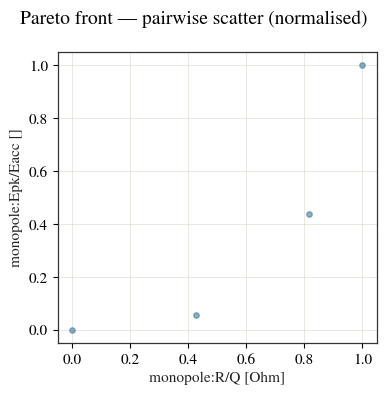

(<Figure size 400x400 with 1 Axes>,
 array([[<Axes: xlabel='monopole:R/Q [Ohm]', ylabel='monopole:Epk/Eacc []'>]],
       dtype=object))

In [7]:
opt.plot_pareto()

100%|██████████| 2/2 [03:12<00:00, 96.24s/it]

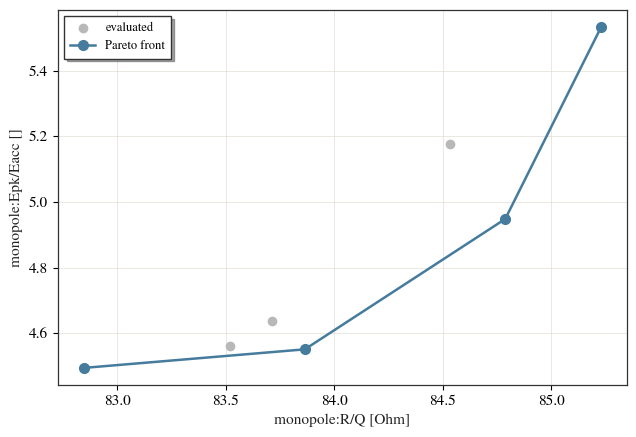

In [8]:
# the same front in physical units, against everything that was evaluated
x, y = opt.objective_vars
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(opt.history[x], opt.history[y], s=36, color='0.72',
           label='evaluated', zorder=2)
front = opt.pareto.sort_values(x)
ax.plot(front[x], front[y], 'o-', color=WARM[0], ms=7, label='Pareto front',
        zorder=3)
ax.set_xlabel(x)
ax.set_ylabel(y)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Higher R/Q costs peak surface field. Which point to build is a machine
decision, not a solver one: the front is the set the solver can defend, and the
choice between its members comes from the gradient limit you are willing to
run at.

## 5. Lines with more than one of the same device

Variable names are `'<label>:<name>'`, and labels come from the elements' own
names. Two cavities named `cav1` and `cav2` give `cav1:A` and `cav2:A`. Two
elements that share a name are suffixed in beam order instead, `cav_1` and
`cav_2`, so the names stay unique without having to be chosen carefully.

In [9]:
def two_cavity_line(names):
    return Assembly([Beampipe(R=R_IRIS, L=100.0, name='bp'),
                     EllipticalCavity(1, MIDCELL, beampipe='both', name=names[0]),
                     EllipticalCavity(1, MIDCELL, beampipe='both', name=names[1])],
                    name='pair')

named = two_cavity_line(('cav1', 'cav2'))
print('distinct names :', named.labels)
print('   cav1:A ->', named.expand_variable('cav1:A'))
print('   cav2:A ->', named.expand_variable('cav2:A'))

repeated = two_cavity_line(('cav', 'cav'))
print('repeated names :', repeated.labels)
print('   cav_2:A ->', repeated.expand_variable('cav_2:A'))

distinct names : ['bp', 'cav1', 'cav2']
   cav1:A -> ['cav1:A_m', 'cav1:A_el', 'cav1:A_er']
   cav2:A -> ['cav2:A_m', 'cav2:A_el', 'cav2:A_er']
repeated names : ['bp', 'cav_1', 'cav_2']
   cav_2:A -> ['cav_2:A_m', 'cav_2:A_el', 'cav_2:A_er']


Both cavities can therefore be optimised at once:

```python
'bounds': {'cav1:A': [57, 62], 'cav2:A': [57, 62]}
```

The two are independent variables: the optimiser will happily give the two
cavities different shapes, and the front it returns includes asymmetric lines.
There is no way to tie one variable to two elements — the `_e` alias ties the
two *ends of one cavity*, not two cavities. To keep a module's cavities
identical, optimise a single cavity in a short line and build the module from
the result.

The tune config names one variable per stage, so tuning a two-cavity line on
`cav1:Req` alone moves only that cavity; the second keeps its nominal
dimensions and the two end up detuned relative to each other. Tune the pair on
both equator radii, or accept that the line is asymmetric and read the modes
accordingly (see [A multi-cavity module](multi_cavity_module.ipynb)).

## 6. Element constraints hold during the search

Each element keeps enforcing its own geometry while the optimiser explores. A
bellows whose corner radii cannot fit is rejected by name at the moment the
candidate is built, so an infeasible region of the search space fails with a
reason rather than at meshing time.

In [10]:
probe = dict(line.parameters)
probe['bellows:R_crest'] = 4.0          # too large for this period
try:
    line.rebuild(probe)
except ValueError as err:
    print(err)

crest corners do not fit: 2 * R_crest * tan(flank_angle/2) = 8 mm exceeds the 6 mm crest flat. Reduce R_crest below 3 mm, or lengthen L_p.


## 7. Rebuilding a chosen candidate

A row of the front is a complete parameter set, so the line it describes can be
rebuilt and re-solved. Taking the highest-R/Q point and checking it lands where
the table says closes the loop between the search and the geometry.

In [11]:
best = opt.pareto.sort_values(x, ascending=False).iloc[0]

chosen = line.rebuild({**line.parameters,
                       **{k: best[k] for k in cols if k.startswith('cav:')}})
chosen.set_name('chosen')
chosen.set_workspace(os.path.join(workspace, 'chosen'))
chosen.eigenmode.run({'polarisation': 'monopole', 'n_modes': 2,
                      'boundary_conditions': 'mm',
                      'mesh_config': {'h': 10, 'p': 2}})

q = chosen.eigenmode.qois
print('from the Pareto table:')
print(f"   R/Q = {best[x]:.2f} Ohm   Epk/Eacc = {best[y]:.3f}")
print('rebuilt and re-solved:')
print(f"   f   = {q['freq [MHz]']:.3f} MHz")
print(f"   R/Q = {q['R/Q [Ohm]']:.2f} Ohm   Epk/Eacc = {q['Epk/Eacc []']:.3f}"
      f"   ff = {q['ff [%]']:.2f} %")

from the Pareto table:
   R/Q = 85.23 Ohm   Epk/Eacc = 5.533
rebuilt and re-solved:
   f   = 800.011 MHz
   R/Q = 85.23 Ohm   Epk/Eacc = 5.533   ff = 100.00 %


## What to take away

* An assembly optimises like any other cavity. The bounds, objectives and tune
  config are the ordinary ones; only the variable names carry an element label.
* Tuning inside the loop keeps the comparison honest: every candidate is
  evaluated at the same frequency, so the objectives measure shape, not detuning.
* Dimensions shared with a neighbour — the iris radius against the beam pipes —
  are not free variables on their own. Vary them together or hold them fixed.
* Each element still enforces its own constraints during the search, so
  infeasible candidates are rejected with a named reason.
* In a line with several of the same device, every element is its own set of
  variables (`cav1:A`, `cav2:A`) and they move independently. Nothing ties two
  elements to one value.
* A Pareto row is a complete parameter set: rebuild it and the line comes back.

See [Assembling a beam line](beam_line_assembly.ipynb) for concatenation, and
[A multi-cavity module](multi_cavity_module.ipynb) for reading the modes of a
longer line.